# Основная часть

## Импорты, seed и устройство

### Импорты библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from pathlib import Path
import json

### Seed и устройство

In [2]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


## Данные и DataLoader

### Dataset (EMNIST)

In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

### train/val split

In [4]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

### DataLoader

In [5]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_loader = DataLoader(test_dataset, batch_size=batch_size)

### Sanity check

In [6]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)
print(x.min(), x.max())

torch.Size([128, 1, 28, 28])
torch.Size([128])
tensor(0.) tensor(1.)


## Модель MLP и цикл обучения

### Модель

In [7]:
class MLP(nn.Module):

    def __init__(self, dropout=0.0, batchnorm=False):

        super().__init__()

        layers = []

        layers.append(nn.Flatten())

        layers.append(nn.Linear(784,256))
        if batchnorm:
            layers.append(nn.BatchNorm1d(256))

        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(256,128))

        if batchnorm:
            layers.append(nn.BatchNorm1d(128))

        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(128,10))

        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)

### Метрика accuracy

In [8]:
def accuracy(pred,y):

    preds = pred.argmax(dim=1)

    return (preds == y).float().mean().item()

### train_one_epoch

In [9]:
def train_one_epoch(model,loader,optimizer,criterion):

    model.train()

    loss_sum = 0
    acc_sum = 0

    for x,y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred,y)

        loss.backward()

        optimizer.step()

        loss_sum += loss.item()
        acc_sum += accuracy(pred,y)

    return loss_sum/len(loader), acc_sum/len(loader)

### evaluate

In [10]:
def evaluate(model,loader,criterion):

    model.eval()

    loss_sum = 0
    acc_sum = 0

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            loss = criterion(pred,y)

            loss_sum += loss.item()
            acc_sum += accuracy(pred,y)

    return loss_sum/len(loader), acc_sum/len(loader)

In [11]:
def train_model(model, train_loader, val_loader, epochs, optimizer):

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(epoch, train_loss, val_loss, val_acc)

    return history

# Эксперименты

In [12]:
from pathlib import Path
import pandas as pd

ARTIFACTS = Path("artifacts")
FIGURES = ARTIFACTS / "figures"

ARTIFACTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

runs = []

## Регуляризация и переобучение

### E1 — Base

In [13]:
class MLP(nn.Module):

    def __init__(self, dropout=0.0, batchnorm=False):

        super().__init__()

        layers = []

        layers.append(nn.Flatten())

        layers.append(nn.Linear(784,256))
        if batchnorm:
            layers.append(nn.BatchNorm1d(256))

        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(256,128))
        if batchnorm:
            layers.append(nn.BatchNorm1d(128))

        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(128,47))   # ← ВАЖНО

        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)

In [14]:
model = MLP().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_e1 = train_model(
    model,
    train_loader,
    val_loader,
    epochs=15,
    optimizer=optimizer
)

runs.append({
    "experiment_id": "E1",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": "256-128 baseline",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e1["val_acc"]),
    "best_val_accuracy": max(history_e1["val_acc"]),
    "best_val_loss": min(history_e1["val_loss"])
})


0 1.2908067178218923 0.8301197684417336 0.7511034604519774
1 0.7001154288755241 0.6578312162625588 0.795462570621469
2 0.5695388188176121 0.5818700404827204 0.8141772598870056
3 0.49985238013538064 0.5395181532633506 0.8256091101694916
4 0.45410492919015544 0.5172919572073188 0.8330243644067796
5 0.41941771735536293 0.49430069613591426 0.8419844632768362
6 0.38972306166980286 0.4978475695275991 0.835496115819209
7 0.3682876669346018 0.49951906780065114 0.8371292372881356
8 0.34384683996227616 0.496814061692879 0.842823093220339
9 0.3278591038276118 0.5020231173536872 0.840527895480226
10 0.3119210364759391 0.5037656968596291 0.8390713276836158
11 0.29696340547174427 0.5126392110592901 0.8371292372881356
12 0.2818506950816364 0.5062330065473999 0.8385858050847458
13 0.26961709768214126 0.5132031423897393 0.8440589689265536
14 0.2571778197026422 0.5352735307257054 0.837747175141243


### E2 — Dropout

In [15]:
model = MLP(dropout=0.3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_e2 = train_model(
    model,
    train_loader,
    val_loader,
    epochs=15,
    optimizer=optimizer
)

best_val_acc = max(history_e2["val_acc"])
best_val_loss = min(history_e2["val_loss"])

runs.append({
    "experiment_id": "E2",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": "256-128 dropout=0.3",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e2["val_acc"]),
    "best_val_accuracy": best_val_acc,
    "best_val_loss": best_val_loss
})

0 1.5555173047045443 0.8594036836408626 0.7384357344632768
1 0.9401662341246368 0.6822379234820436 0.7852665960451978
2 0.8173980725572464 0.6189623640081977 0.8023040254237288
3 0.7441658324806403 0.5722518265247345 0.8143979519774012
4 0.701998932606785 0.5437200204127253 0.8205773305084746
5 0.670556888047685 0.5225854194433676 0.8262270480225988
6 0.6460429379280578 0.5087220707518906 0.831347104519774
7 0.6214964921170093 0.5009180022835058 0.8343043785310734
8 0.611262114589096 0.4886227995999115 0.8365112994350282
9 0.595746106839349 0.48430040966993 0.8377030367231638
10 0.5863431297295483 0.4784073112374645 0.838718220338983
11 0.5740763543345404 0.474325979833549 0.8401306497175142
12 0.567511315886856 0.47076691156726774 0.8409251412429378
13 0.5573855233530626 0.4673249497588745 0.843794138418079
14 0.5496112711040686 0.45962204098027976 0.8464424435028248


### E3 — BatchNorm

In [16]:
model = MLP(batchnorm=True).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_e3 = train_model(
    model,
    train_loader,
    val_loader,
    epochs=15,
    optimizer=optimizer
)

best_val_acc = max(history_e3["val_acc"])
best_val_loss = min(history_e3["val_loss"])

runs.append({
    "experiment_id": "E3",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": "256-128 batchnorm",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e3["val_acc"]),
    "best_val_accuracy": best_val_acc,
    "best_val_loss": best_val_loss
})

0 0.9923807073146739 0.6082911225362012 0.8049964689265536
1 0.5312903390708544 0.5134303781945827 0.8306408898305084
2 0.4502054984265185 0.4814628982274546 0.8355843926553672
3 0.4023335933051211 0.4806596049144443 0.8410575564971752
4 0.3711871942307087 0.4640834982280677 0.8421168785310734
5 0.34741624295711515 0.45556671260777165 0.8479872881355932
6 0.3217348360000773 0.4668764551143862 0.8439706920903954
7 0.30632815954955755 0.4650444625797918 0.846486581920904
8 0.2878817103855999 0.4671983521873668 0.8481197033898306
9 0.2743272928481406 0.47012563445473793 0.847413488700565
10 0.2621984638960649 0.4731625986132918 0.8476341807909604
11 0.251694924939186 0.4900664769660282 0.8439706920903954
12 0.23863719182868376 0.4873721437097269 0.8475900423728814
13 0.22992365390907787 0.502866124871087 0.8427348163841808
14 0.2204736243854178 0.5089770609376121 0.8422492937853108


### E4 — EarlyStopping

In [17]:
model = MLP(dropout=0.3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.CrossEntropyLoss()

epochs = 30
patience = 4

best_val_acc = 0
patience_counter = 0

history_e4 = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion
    )

    history_e4["train_loss"].append(train_loss)
    history_e4["val_loss"].append(val_loss)
    history_e4["train_acc"].append(train_acc)
    history_e4["val_acc"].append(val_acc)

    print(epoch, train_loss, val_loss, val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0

        torch.save(
            model.state_dict(),
            ARTIFACTS / "best_model.pt"
        )

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break


runs.append({
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": "256-128 dropout=0.3 earlystop",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e4["val_acc"]),
    "best_val_accuracy": max(history_e4["val_acc"]),
    "best_val_loss": min(history_e4["val_loss"])
})

0 1.55640602196362 0.8563577041114118 0.7388771186440678
1 0.9393264193061396 0.6696962207387396 0.7880914548022598
2 0.8155673026193119 0.5999746955720718 0.805570268361582
3 0.7406892619234451 0.5658904601961879 0.8144862288135594
4 0.6986025291554472 0.5439002566081655 0.8219456214689266
5 0.666676596842759 0.5194763992465822 0.8275953389830508
6 0.6399900261814713 0.511110902674454 0.8297581214689266
7 0.6228639309710645 0.5035782383996888 0.8312146892655368
8 0.6057198471211372 0.49372392387713415 0.834525070621469
9 0.5906177082805769 0.48872903578698973 0.8362906073446328
10 0.5810651482842493 0.48101466490050493 0.8403072033898306
11 0.5740021063503644 0.4774138181559784 0.840527895480226
12 0.5645011427131951 0.47332526145681825 0.8427789548022598
13 0.5543260679600087 0.4724398378261739 0.8408368644067796
14 0.5500321937368271 0.463474297254099 0.845118290960452
15 0.5411531729055634 0.46840687003512843 0.8399982344632768
16 0.5331882548247668 0.4568149494586018 0.84701624293

## LR, оптимизаторы, weight decay

### O1 — слишком большой LR

In [18]:
model = MLP(dropout=0.3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-1)

history_o1 = train_model(
    model,
    train_loader,
    val_loader,
    epochs=6,
    optimizer=optimizer
)

runs.append({
    "experiment_id": "O1",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": "dropout=0.3",
    "optimizer": "Adam",
    "lr": 1e-1,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_o1["val_acc"]),
    "best_val_accuracy": max(history_o1["val_acc"]),
    "best_val_loss": min(history_o1["val_loss"])
})

0 4.056962297656012 3.868630813340009 0.0200829802259887
1 3.8817998585126077 3.8916370774393028 0.020480225988700564
2 3.885418985583258 3.8694623392180536 0.020921610169491525
3 3.864140755403126 3.8683346705248125 0.020833333333333332
4 3.86468866091248 3.866845070305517 0.021495409604519775
5 3.8651005044896554 3.870076202403354 0.020038841807909605


### O2 — слишком маленький LR

In [19]:
model = MLP(dropout=0.3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-5)

history_o2 = train_model(
    model,
    train_loader,
    val_loader,
    epochs=6,
    optimizer=optimizer
)

runs.append({
    "experiment_id": "O2",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": "dropout=0.3",
    "optimizer": "Adam",
    "lr": 1e-5,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_o2["val_acc"]),
    "best_val_accuracy": max(history_o2["val_acc"]),
    "best_val_loss": min(history_o2["val_loss"])
})

0 3.8107641937039425 3.7388090521602306 0.14225812146892655
1 3.6299366301678595 3.460244077747151 0.2552083333333333
2 3.337267277088571 3.109239455670287 0.3167372881355932
3 3.037672385425432 2.7804514162958007 0.3840042372881356
4 2.787202935523175 2.5141946313071384 0.441163488700565
5 2.5889682850939164 2.3081237986936407 0.4791225282485876


### O3 — SGD + momentum + weight decay

In [20]:
model = MLP(dropout=0.3).to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4
)

history_o3 = train_model(
    model,
    train_loader,
    val_loader,
    epochs=12,
    optimizer=optimizer
)

runs.append({
    "experiment_id": "O3",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": "dropout=0.3",
    "optimizer": "SGD",
    "lr": 1e-2,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "epochs_trained": len(history_o3["val_acc"]),
    "best_val_accuracy": max(history_o3["val_acc"]),
    "best_val_loss": min(history_o3["val_loss"])
})

0 2.4450985130688823 1.3269110803550246 0.6230579096045198
1 1.3302953746301909 0.9772579040231004 0.7140713276836158
2 1.0914384566300304 0.8297612444829132 0.7552083333333334
3 0.9733641282041022 0.7386373150146613 0.7753354519774012
4 0.8941257588406827 0.6917238247259861 0.784472104519774
5 0.8370878697287106 0.6482298215903805 0.7961246468926554
6 0.7959810071803154 0.6127699091609589 0.8063647598870056
7 0.7606446962407295 0.5945773102806113 0.8104254943502824
8 0.7330796989143318 0.5757725415593486 0.8164283192090396
9 0.7155633212826776 0.5575000882822242 0.8200035310734464
10 0.6922223553167167 0.5488320083941444 0.822651836158192
11 0.6754871040371293 0.5347766775195881 0.8270215395480226


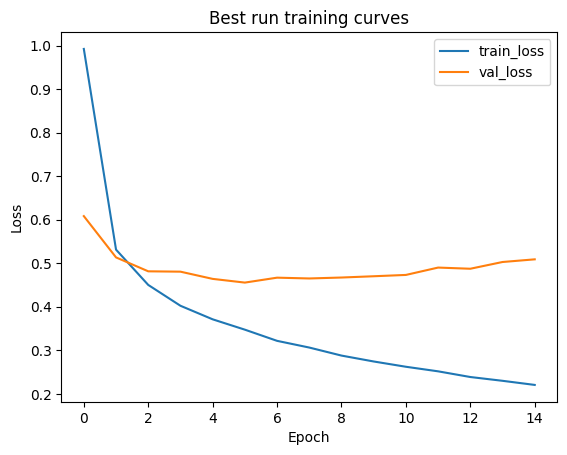

In [21]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_e3["train_loss"], label="train_loss")
plt.plot(history_e3["val_loss"], label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best run training curves")

plt.legend()

plt.savefig("artifacts/figures/curves_best.png")

plt.show()

# Артефакты

## runs.csv

In [22]:
df = pd.DataFrame(runs)

df.to_csv(ARTIFACTS / "runs.csv", index=False)

df

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,256-128 baseline,Adam,0.00100,0.0,0.0000,15,0.844059,0.494301
1,E2,EMNIST,42,256-128 dropout=0.3,Adam,0.00100,0.0,0.0000,15,0.846442,0.459622
2,E3,EMNIST,42,256-128 batchnorm,Adam,0.00100,0.0,0.0000,15,0.848120,0.455567
3,E4,EMNIST,42,256-128 dropout=0.3 earlystop,Adam,0.00100,0.0,0.0000,30,0.849576,0.447935
4,O1,EMNIST,42,dropout=0.3,Adam,0.10000,0.0,0.0000,6,0.021495,3.866845
5,O2,EMNIST,42,dropout=0.3,Adam,0.00001,0.0,0.0000,6,0.479123,2.308124
6,O3,EMNIST,42,dropout=0.3,SGD,0.01000,0.9,0.0001,12,0.827022,0.534777


## Финальная проверка на test

In [23]:
model.load_state_dict(torch.load(ARTIFACTS / "best_model.pt"))

criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model, test_loader, criterion)

print("Test accuracy:", test_acc)

Test accuracy: 0.845974550360725


## LR extremes

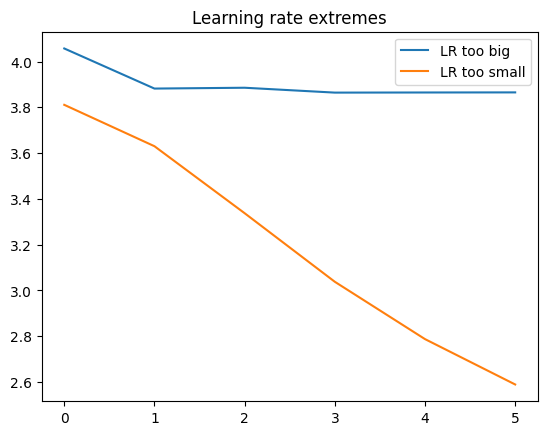

In [24]:
plt.plot(history_o1["train_loss"], label="LR too big")
plt.plot(history_o2["train_loss"], label="LR too small")

plt.legend()
plt.title("Learning rate extremes")

plt.savefig(FIGURES / "curves_lr_extremes.png")
plt.show()

## best_config

In [25]:
best_config = {
    "dataset": "EMNIST",
    "seed": seed,

    "model": {
        "type": "MLP",
        "input_dim": 784,
        "hidden_layers": [256, 128],
        "output_dim": 47,
        "activation": "ReLU",
        "dropout": 0.3,
        "batchnorm": False
    },

    "training": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": batch_size,
        "max_epochs": 30,
        "early_stopping_patience": 4
    }
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("best_config.json saved")

best_config.json saved
